# Stock Risk & Return Analysis

## Project Overview
This project analyzes the historical risk and return characteristics of five major technology companies:

- Apple
- Amazon
- Facebook
- Google
- Microsoft



### Financial Metrics
- Average Daily Return
- Annualized Return
- Annualized Volatility
- Sharpe Ratio
- Maximum Drawdown

>


## 1. Import Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")


## 2. Loading the Dataset

The project dataset contains historical stock-price observations and daily returns.

In [56]:
import os
import pandas as pd

files = os.listdir("/content")
print(files)



['.config', 'FAANG_Combined_Data_Separated (3).xlsx', 'FAANG_Combined_Data_Separated (3) (1).xlsx', 'sample_data']


In [57]:
file_path = "/content/FAANG_Combined_Data_Separated (3).xlsx"

xls = pd.ExcelFile(file_path)
xls.sheet_names

['README',
 'Combined_Data',
 'Data_Validation',
 'Risk_Return_Analysis',
 'Apple',
 'Amazon',
 'Facebook',
 'Google',
 'Microsoft']

In [58]:
import pandas as pd

file_path = "/content/FAANG_Combined_Data_Separated (3).xlsx"

df = pd.read_excel(file_path, sheet_name="Combined_Data")

df.head()

,Date,Company,Open,High,Low,Close,Adj Close,Volume,Daily_Return
0,2015-01-02,Apple,27.847500,27.860001,26.837500,27.332500,24.745996,212818400,NaN
1,2015-01-05,Apple,27.072500,27.162500,26.352501,26.562500,24.048864,257142000,-0.028172
2,2015-01-06,Apple,26.635000,26.857500,26.157499,26.565001,24.051125,263188400,0.000094
3,2015-01-07,Apple,26.799999,27.049999,26.674999,26.937500,24.388372,160423600,0.014022
4,2015-01-08,Apple,27.307501,28.037500,27.174999,27.972500,25.325430,237458000,0.038422


## 3. Understand the Data

In [59]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Shape: (8805, 9)

Columns:
['Date', 'Company', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return']

Data types:


,0
Date,datetime64[ns]
Company,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64
Daily_Return,float64



Missing values:


,0
Date,0
Company,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Daily_Return,5



Duplicate rows: 0


## 4. Data Cleaning

In [60]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df.drop_duplicates().copy()


if {"company", "date"}.issubset(df.columns):
    df = df.sort_values(["company", "date"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
display(df.head())


Cleaned shape: (8805, 9)


,date,company,open,high,low,close,adj_close,volume,daily_return
0,2015-01-02,Amazon,312.579987,314.750000,306.959991,308.519989,308.519989,2783200,NaN
1,2015-01-05,Amazon,307.010010,308.380005,300.850006,302.190002,302.190002,2774200,-0.020517
2,2015-01-06,Amazon,302.239990,303.000000,292.380005,295.290009,295.290009,3519000,-0.022833
3,2015-01-07,Amazon,297.500000,301.279999,295.329987,298.420013,298.420013,2640300,0.010600
4,2015-01-08,Amazon,300.320007,303.140015,296.109985,300.459991,300.459991,3088400,0.006836


## 5. Exploratory Data Analysis

In [61]:
display(df.describe(include="all"))


,date,company,open,high,low,close,adj_close,volume,daily_return
count,8805,8805,8805.000000,8805.000000,8805.000000,8805.000000,8805.000000,8805.000000,8800.000000
unique,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Amazon,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1761,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2018-07-01 22:28:24.940374784,NaN,648.981748,655.499069,642.193588,649.069079,648.070365,39188676.833390,0.001267
min,2015-01-02 00:00:00,NaN,22.500000,22.917500,22.367500,22.584999,21.036304,346800.000000,-0.189609
25%,2016-09-30 00:00:00,NaN,83.470001,84.099998,82.919998,83.300003,81.529999,2974100.000000,-0.006611
50%,2018-07-02 00:00:00,NaN,199.910004,202.470001,197.740005,200.389999,199.320007,17295900.000000,0.001077
75%,2020-04-01 00:00:00,NaN,971.789978,976.770020,962.500000,970.669983,970.669983,37990400.000000,0.010122
max,2021-12-29 00:00:00,NaN,3744.000000,3773.080078,3696.790039,3731.409912,3731.409912,648825200.000000,0.160524


In [62]:
if "company" in df.columns:
    display(df["company"].value_counts())


,count
company,
Amazon,1761
Apple,1761
Facebook,1761
Google,1761
Microsoft,1761


## 6. Daily Returns

In [63]:
import pandas as pd
df = pd.read_excel(file_path, sheet_name="Combined_Data")

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")


df = df.drop_duplicates().copy()

if {"company", "date"}.issubset(df.columns):
    df = df.sort_values(["company", "date"]).reset_index(drop=True)


if "daily_return" not in df.columns:
    price_col = next(
        (c for c in ["adj_close", "adjusted_close", "close"] if c in df.columns),
        None
    )

    if price_col is None:

        raise ValueError("No daily_return or price column was found even after attempting to load 'Combined_Data'.")

    df["daily_return"] = (
        df.groupby("company")[price_col]
          .pct_change()
    )

display(df[["company", "date", "daily_return"]].head(10))


,company,date,daily_return
0,Amazon,2015-01-02,NaN
1,Amazon,2015-01-05,-0.020517
2,Amazon,2015-01-06,-0.022833
3,Amazon,2015-01-07,0.010600
4,Amazon,2015-01-08,0.006836
5,Amazon,2015-01-09,-0.011749
6,Amazon,2015-01-12,-0.018590
7,Amazon,2015-01-13,0.011427
8,Amazon,2015-01-14,-0.004987
9,Amazon,2015-01-15,-0.021550


## 7. Average Daily Return

In [64]:
avg_daily_return = (
    df.groupby("company")["daily_return"]
      .mean()
      .rename("Average Daily Return")
)

display((avg_daily_return * 100).round(3).sort_values(ascending=False))


,Average Daily Return
company,
Amazon,0.154000
Microsoft,0.135000
Apple,0.129000
Google,0.112000
Facebook,0.104000


## 8. Annualized Return

## 9. Annualized Volatility

In [77]:
import pandas as pd
import os

files = os.listdir("/content")
print("Files in Colab:")
print(files)

file_path = "/content/FAANG_Combined_Data_Separated (3).xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Combined_Data"
)

df.columns = df.columns.str.strip()

print("\nDataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Files in Colab:
['.config', 'FAANG_Combined_Data_Separated (3).xlsx', 'FAANG_Combined_Data_Separated (3) (1).xlsx', 'sample_data']

Dataset loaded successfully!
Shape: (8805, 9)

Columns:
['Date', 'Company', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return']


,Date,Company,Open,High,Low,Close,Adj Close,Volume,Daily_Return
0,2015-01-02,Apple,27.847500,27.860001,26.837500,27.332500,24.745996,212818400,NaN
1,2015-01-05,Apple,27.072500,27.162500,26.352501,26.562500,24.048864,257142000,-0.028172
2,2015-01-06,Apple,26.635000,26.857500,26.157499,26.565001,24.051125,263188400,0.000094
3,2015-01-07,Apple,26.799999,27.049999,26.674999,26.937500,24.388372,160423600,0.014022
4,2015-01-08,Apple,27.307501,28.037500,27.174999,27.972500,25.325430,237458000,0.038422


In [66]:
import pandas as pd

file_path = "/content/FAANG_Combined_Data_Separated (3).xlsx"

df = pd.read_excel(file_path, sheet_name="Combined_Data")

df.head()

,Date,Company,Open,High,Low,Close,Adj Close,Volume,Daily_Return
0,2015-01-02,Apple,27.847500,27.860001,26.837500,27.332500,24.745996,212818400,NaN
1,2015-01-05,Apple,27.072500,27.162500,26.352501,26.562500,24.048864,257142000,-0.028172
2,2015-01-06,Apple,26.635000,26.857500,26.157499,26.565001,24.051125,263188400,0.000094
3,2015-01-07,Apple,26.799999,27.049999,26.674999,26.937500,24.388372,160423600,0.014022
4,2015-01-08,Apple,27.307501,28.037500,27.174999,27.972500,25.325430,237458000,0.038422


In [67]:
annualized_volatility = (
    df.groupby("Company")["Daily_Return"]
      .std()
      .mul(np.sqrt(252))
      .rename("Annualized Volatility")
)

display(
    (annualized_volatility * 100)
    .round(2)
    .sort_values(ascending=False)
)

,Annualized Volatility
Company,
Facebook,31.530000
Amazon,30.120000
Apple,29.040000
Microsoft,26.970000
Google,26.500000


## 10. Sharpe Ratio

In [68]:
risk_free_rate = 0.0


sharpe_ratio = (
    (annualized_return - risk_free_rate)
    / annualized_volatility
).rename("Sharpe Ratio")

display(
    sharpe_ratio
    .round(2)
    .sort_values(ascending=False)
)

,Sharpe Ratio
Company,
Amazon,1.290000
Microsoft,1.260000
Apple,1.120000
Google,1.060000
Facebook,0.830000


## 11. Maximum Drawdown

In [69]:
price_col = "Adj Close"

def maximum_drawdown(group):
    prices = group[price_col].dropna()

    running_peak = prices.cummax()

    drawdown = prices / running_peak - 1

    return drawdown.min()


max_drawdown = (
    df.groupby("Company")
    .apply(maximum_drawdown, include_groups=False)
    .rename("Maximum Drawdown")
)

display(
    (max_drawdown * 100)
    .round(2)
    .sort_values(ascending=True)
)

,Maximum Drawdown
Company,
Facebook,-42.960000
Apple,-38.520000
Amazon,-34.100000
Google,-30.790000
Microsoft,-28.040000


## 12. Final Company Comparison

In [70]:
summary = pd.concat(
    [
        avg_daily_return,
        annualized_return,
        annualized_volatility,
        sharpe_ratio,
        max_drawdown
    ],
    axis=1
)

summary = summary.sort_values("Annualized Return", ascending=False)

display(
    summary.style.format({
        "Average Daily Return": "{:.3%}",
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}",
        "Maximum Drawdown": "{:.2%}"
    })
)


,Average Daily Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Amazon,0.154%,38.81%,30.12%,1.29,-34.10%
Microsoft,0.135%,33.95%,26.97%,1.26,-28.04%
Apple,0.129%,32.60%,29.04%,1.12,-38.52%
Google,0.112%,28.17%,26.50%,1.06,-30.79%
Facebook,0.104%,26.13%,31.53%,0.83,-42.96%


## 13. Risk–Return Visualization

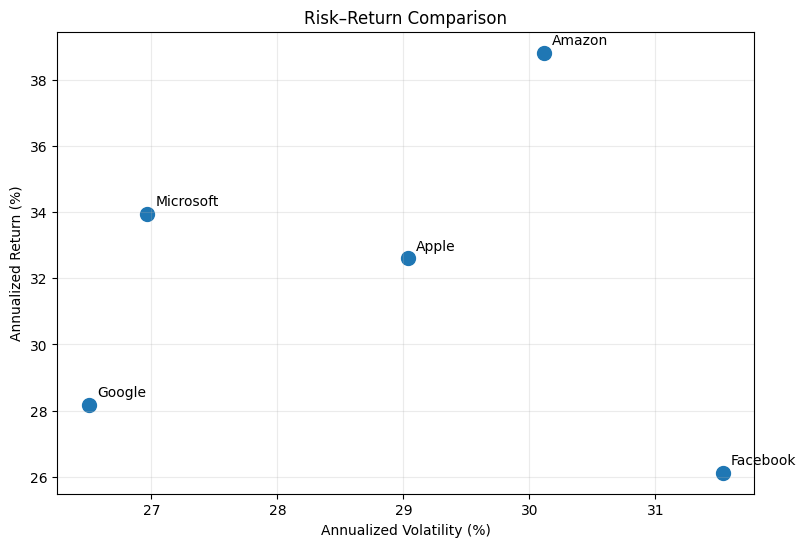

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    summary["Annualized Volatility"] * 100,
    summary["Annualized Return"] * 100,
    s=100
)

for company, row in summary.iterrows():
    plt.annotate(
        company,
        (
            row["Annualized Volatility"] * 100,
            row["Annualized Return"] * 100
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Risk–Return Comparison")
plt.grid(alpha=0.25)
plt.show()


## 14. Metric Comparison Charts

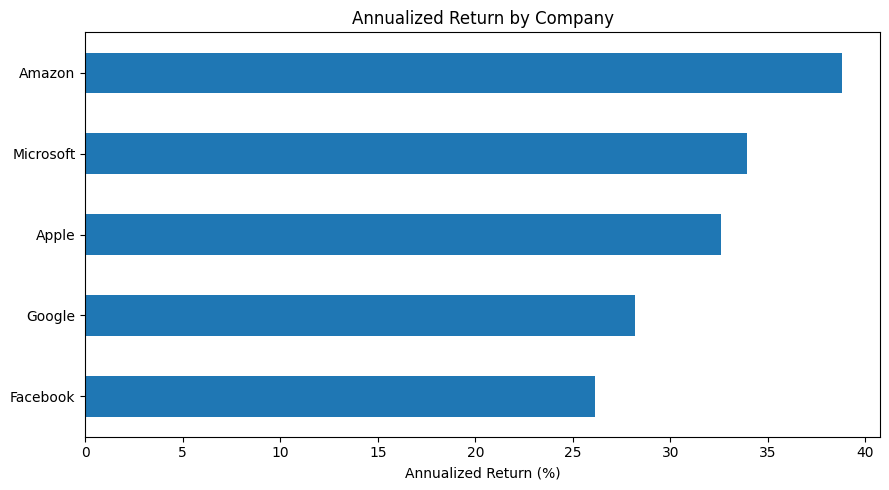

In [72]:
# Annualized Return
summary["Annualized Return"].sort_values().mul(100).plot(
    kind="barh", figsize=(9, 5), title="Annualized Return by Company"
)
plt.xlabel("Annualized Return (%)")
plt.tight_layout()
plt.show()


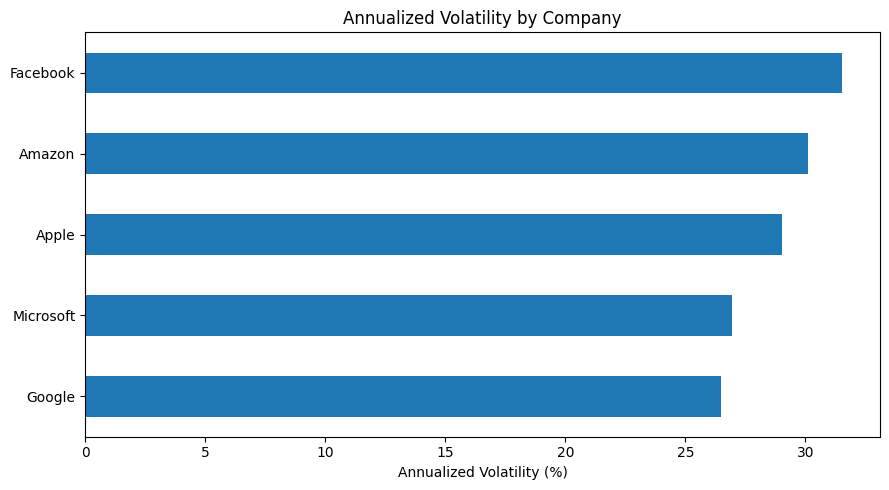

In [73]:
# Annualized Volatility
summary["Annualized Volatility"].sort_values().mul(100).plot(
    kind="barh", figsize=(9, 5), title="Annualized Volatility by Company"
)
plt.xlabel("Annualized Volatility (%)")
plt.tight_layout()
plt.show()


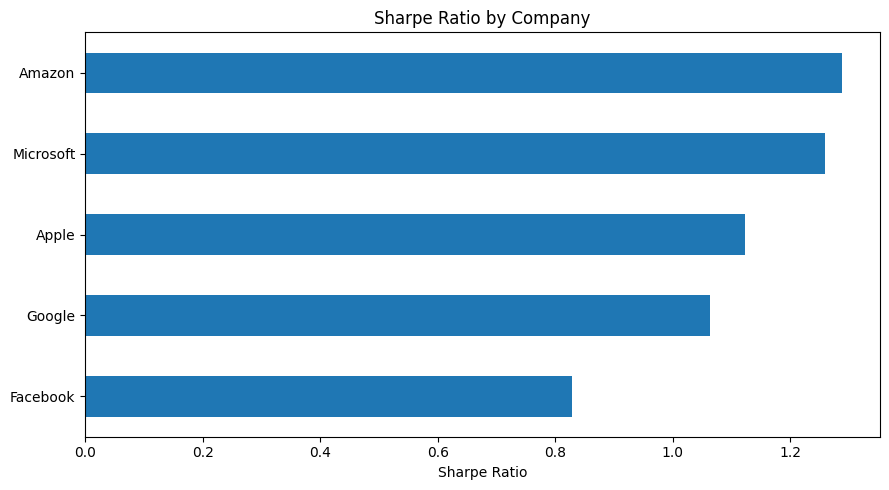

In [74]:
# Sharpe Ratio
summary["Sharpe Ratio"].sort_values().plot(
    kind="barh", figsize=(9, 5), title="Sharpe Ratio by Company"
)
plt.xlabel("Sharpe Ratio")
plt.tight_layout()
plt.show()


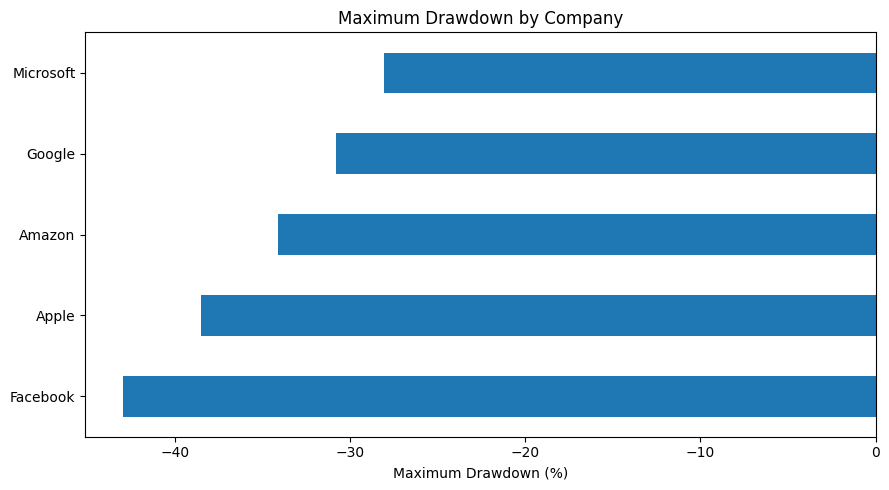

In [75]:
# Maximum Drawdown
summary["Maximum Drawdown"].sort_values().mul(100).plot(
    kind="barh", figsize=(9, 5), title="Maximum Drawdown by Company"
)
plt.xlabel("Maximum Drawdown (%)")
plt.tight_layout()
plt.show()


## 15. Key Financial Insights

In [76]:
best_return = summary["Annualized Return"].idxmax()
lowest_volatility = summary["Annualized Volatility"].idxmin()
best_sharpe = summary["Sharpe Ratio"].idxmax()
smallest_drawdown = summary["Maximum Drawdown"].idxmax()
largest_drawdown = summary["Maximum Drawdown"].idxmin()

print(f"Highest annualized return: {best_return}")
print(f"Lowest annualized volatility: {lowest_volatility}")
print(f"Highest Sharpe ratio: {best_sharpe}")
print(f"Smallest maximum drawdown: {smallest_drawdown}")
print(f"Largest maximum drawdown: {largest_drawdown}")


Highest annualized return: Amazon
Lowest annualized volatility: Google
Highest Sharpe ratio: Amazon
Smallest maximum drawdown: Microsoft
Largest maximum drawdown: Facebook


## 16. Conclusion

The analysis compares historical return, volatility, risk-adjusted performance, and downside risk across Apple, Amazon, Facebook, Google, and Microsoft.


